In [22]:
from sctoolbox.utils.jupyter import bgcolor, _compare_version

# change the background of input cells
bgcolor("PowderBlue", select=[2, 4, 6, 8, 10, 13, 15])

nb_name = "0A1_ligand_receptor.ipynb"

_compare_version(nb_name)

# 0A - Receptor-Ligand Analysis
<hr style="border:2px solid black"> </hr>

## 1 - Description

**Requires an anndata object with precomputed clusters. Clusters can be generated with the clustering notebook (`rna_analysis/notebooks/04_clustering.ipynb`).**

Receptor-ligand interactions play a crucial role in mediating cellular communication and signaling processes in biological systems. In the context of single-cell data analysis, studying receptor-ligand interactions provides insights into cell-cell communication networks and their impact on various cellular functions and behaviors.  
This notebook provides the tools to investigate and visualize the ligand-receptor interactions between conditions and/or clusters.

--------------

## 2 - Setup

In [3]:
import sctoolbox.tools.receptor_ligand as rl
import sctoolbox.utils as utils
import pandas as pd
from sctoolbox import settings
settings.settings_from_config("config.yaml", key="0A1")

with pd.option_context("display.max.rows", None, "display.max_colwidth", None):
    display(utils.general.get_version_report(report="versions.yml"))

/mnt/workspace2/hschult/.conda/sctoolbox/lib/python3.12/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


[WARNING] Log file '../logs/0A1_log.txt' already exists. The file will be overwritten since 'overwrite_log' is set to True.


,Name,Version
0,Python,"3.12.12 | packaged by conda-forge | (main, Oct 22 2025, 23:25:55) [GCC 14.3.0]"
1,sctoolbox,NA
2,scanpy,1.11.5
3,pandas,2.3.3
4,anndata,0.12.6
5,numpy,2.3.5


--------------

## 3 - Load adata

<h1><center>⬐ Fill in input data here ⬎</center></h1>

In [4]:
anndata_file = "anndata_scanpro.h5ad"

___

In [5]:
adata = utils.adata.load_h5ad(anndata_file)

with pd.option_context("display.max.rows", 5, "display.max.columns", None):
    display(adata)
    display(adata.obs)
    display(adata.var)

[INFO] The adata object was loaded from: ../adatas/anndata_scanpro.h5ad


AnnData object with n_obs × n_vars = 51409 × 25904
    obs: 'paper_cluster', 'filename', 'sample', 'timepoint', 'batch', 'Paper cell type', 'Spatial expression domain', 'total_counts', 'log1p_total_counts', 'total_counts_is_mito', 'log1p_total_counts_is_mito', 'pct_counts_is_mito', 'total_counts_is_ribo', 'log1p_total_counts_is_ribo', 'pct_counts_is_ribo', 'doublet_score', 'predicted_doublet', 'predicted_sex', 'n_genes', 'log1p_n_genes', 'S_score', 'G2M_score', 'phase', 'Combined timepoint clustering', '1.5 dpf pred. cell type', '2 dpf pred. cell type', '3 dpf pred. cell type', '5 dpf pred. cell type', '14 dpf pred. cell type', '60 dpf pred. cell type', '150 dpf pred. cell type', 'Combined pred. cell type', 'leiden', 'LISI_score_X_pca', 'LISI_score_X_umap', 'sample_density', 'timepoint_density', 'leiden_0.1', 'leiden_0.2', 'leiden_0.3', 'leiden_0.4', 'leiden_0.5', 'leiden_0.6', 'leiden_0.7', 'leiden_0.8', 'leiden_0.9', 'leiden_1.0', 'leiden_1.1', 'leiden_1.2', 'leiden_1.3', 'leiden_1.4

,paper_cluster,filename,sample,timepoint,batch,Paper cell type,Spatial expression domain,total_counts,log1p_total_counts,total_counts_is_mito,log1p_total_counts_is_mito,pct_counts_is_mito,total_counts_is_ribo,log1p_total_counts_is_ribo,pct_counts_is_ribo,doublet_score,predicted_doublet,predicted_sex,n_genes,log1p_n_genes,S_score,G2M_score,phase,Combined timepoint clustering,1.5 dpf pred. cell type,2 dpf pred. cell type,3 dpf pred. cell type,5 dpf pred. cell type,14 dpf pred. cell type,60 dpf pred. cell type,150 dpf pred. cell type,Combined pred. cell type,leiden,LISI_score_X_pca,LISI_score_X_umap,sample_density,timepoint_density,leiden_0.1,leiden_0.2,leiden_0.3,leiden_0.4,leiden_0.5,leiden_0.6,leiden_0.7,leiden_0.8,leiden_0.9,leiden_1.0,leiden_1.1,leiden_1.2,leiden_1.3,leiden_1.4,leiden_1.5,leiden_1.6,leiden_1.7,leiden_1.8,leiden_1.9,clustering,MR_symbol_leiden_1.5,SCSA_symbol_leiden_1.5,MR_score_leiden_1.5,SCSA_score_leiden_1.5,MR_ui_leiden_1.5,SCSA_ui_leiden_1.5
AAACCTGGTTCACCTC-1-1.5dpf,2,GSM5402428_scRNAseq_Sox10_Cre_bact_BtR_1.5dpf_...,GSM5402428,1.5dpf,rep_1,Mesenchyme,Dorsal,6103.0,8.716700,72.0,4.290460,1.179748,2230.0,7.710205,36.539406,0.056507,False,Male,1755,7.470794,0.967606,0.935372,S,1_1.5dpf,Periosteum,NaN,NaN,NaN,NaN,NaN,NaN,Periosteum,0,2.106292,1.805305,0.363366,0.363366,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,Cycling,Cycling,Mesenchyme,Cycling,Mesenchyme,Cycling
AAACCTGTCCCAAGAT-1-1.5dpf,4,GSM5402428_scRNAseq_Sox10_Cre_bact_BtR_1.5dpf_...,GSM5402428,1.5dpf,rep_1,Neuronal,NaN,2433.0,7.797291,20.0,3.044523,0.822030,821.0,6.711740,33.744347,0.017997,False,Male,779,6.659294,-0.260912,-0.043198,G1,2_1.5dpf,Hyaline cartilage,NaN,NaN,NaN,NaN,NaN,NaN,Hyaline cartilage,1,2.356823,3.274661,0.217232,0.217232,3,4,2,2,2,3,7,5,3,2,3,3,2,2,3,3,3,3,2,3,Neuronal,Otic cells,Neuronal,Otic cells,Neuronal,Otic cells
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCATCAACACCA-3-150dpf,9,GSM5402443_scRNAseq_Sox10_Cre_bact_BtR_150dpf_...,GSM5402443,150dpf,rep_3,Teeth,NaN,1300.0,7.170888,85.0,4.454347,6.538462,561.0,6.331502,43.153847,0.059896,False,Male,360,5.888878,-0.133821,-0.121936,G1,1_150dpf,NaN,NaN,NaN,NaN,NaN,NaN,Stroma,Stroma,19,1.993680,1.404883,0.343041,0.653931,6,7,10,7,11,12,16,18,15,20,23,15,15,16,19,26,18,30,24,19,Stroma,Perivascular,Stroma,Perivascular,Stroma,Perivascular
TTTGTCATCCGAACGC-3-150dpf,6,GSM5402443_scRNAseq_Sox10_Cre_bact_BtR_150dpf_...,GSM5402443,150dpf,rep_3,Gill cartilage,NaN,3631.0,8.197538,28.0,3.367296,0.771137,1142.0,7.041412,31.451393,0.074581,False,Male,909,6.813445,-0.262674,-0.138711,G1,9_150dpf,NaN,NaN,NaN,NaN,NaN,NaN,Gill cartilage,Gill cartilage,21,1.009526,1.000000,0.728333,0.689964,9,10,13,13,15,17,18,19,21,22,24,26,26,28,28,29,29,32,33,28,Gill cartilage,Gill cartilage,Gill cartilage,Gill cartilage,Gill cartilage,Gill cartilage


,gene_id,is_mito,is_ribo,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,highly_variable,means,dispersions,dispersions_norm
gene_symbol,,,,,,,,,,,,,
ABR (1 of many),ENSDARG00000059587,False,False,63,0.021192,0.020971,97.913907,64.0,4.174387,False,0.024158,0.771868,0.093256
ACKR2,ENSDARG00000086314,False,False,1,0.000331,0.000331,99.966887,1.0,0.693147,False,0.003503,1.402789,1.179807
...,...,...,...,...,...,...,...,...,...,...,...,...,...
zzef1,ENSDARG00000094380,False,False,56,0.018543,0.018373,98.145695,56.0,4.043051,False,0.009438,0.886365,0.290440
zzz3,ENSDARG00000077581,False,False,241,0.083444,0.080145,92.019868,252.0,5.533390,False,0.036410,0.648544,-0.119127


--------------

## 4 - Download receptor-ligand database

Supply a receptor-ligand database. This can be done in two ways:

1. Provide the name of a recognized [LIANA resource](https://liana-py.readthedocs.io/en/latest/notebooks/prior_knowledge.html#Ligand-Receptor-Interactions).

2. Provide a path or link to a table that consists of at least two columns - one for the receptors and one for the    ligands. Each row of this table must correspond to a unique interaction, e.g. `http://tcm.zju.edu.cn/celltalkdb/download/processed_data/human_lr_pair.txt`

The databse will be stored in the adata object (`adata.uns['receptor-ligand]['database']`).

<h1><center>⬐ Fill in input data here ⬎</center></h1>

In [6]:
# Either a path/link to a table or the name of a LIANA resource
db_path = 'https://raw.githubusercontent.com/DanioTalk/daniotalk/refs/heads/master/Database/Database.csv'

ligand_column = 'ZFIN_SYMBOL_LIG'
receptor_column = 'ZFIN_SYMBOL_REC'

sep=","

_______

In [7]:
rl.download_db(adata=adata,
               db_path=db_path,
               ligand_column=ligand_column,
               receptor_column=receptor_column,
               inplace=True,
               overwrite=False,
               sep=sep,
               report=("01_ligand_receptor_database.md", "01_ligand_receptor_table.png"))

--------------

## 5 - Compute interactions
Calculate a table of receptor-ligand interactions between given groups using the previously downloaded database. The resulting table is used to generate the plots in the next steps.
The resulting table contains:
- __receptor-/ ligand score__: Gene enriched (`> 0`) or depleted (`< 0`) for specific group.
- __receptor-/ ligand percent__: Percent of cells in a group expressing gene.
- __interaction score__: Receptor-ligand pair enriched (`> 0`) or depleted (`< 0`) between groups.

The interaction score is calculated by adding the receptor score to the ligand score with each score being multiplied by the respective cluster proportion to correct for cluster size:

$$\text{interaction_score} = score_{receptor} \times proportion_{\text{receptor cluster}} + score_{ligand} \times proportion_{\text{ligand cluster}} $$

The result table is stored in the adata object (`adata.uns['receptor-ligand']['interactions']`)

<h1><center>⬐ Fill in input data here ⬎</center></h1>

In [8]:
# Comput interactions
cluster_col = "MR_ui_leiden_1.5"  # Name of the cluster column in adata.obs.
normalize = None  # Normalize cell counts.
                  # Scales expression values to correct for different cluster sizes, using this as the reference cell count.
                  # If None, max cluster size will be used.
gene_col = None   # Column in adata.var that holds gene symbols/ ids. Set to None to use index
overwrite = False # Overwrite existing interaction table

# Data layer (advanced)
# decide which processing state of the data should be used for computation
# available layers can be seen above, e.g. "norm" to use normalized data
# it is recommended to use raw or normalized data for statistical testing
layer = "norm"

_______

In [9]:
rl.calculate_interaction_table(adata=adata,
                               cluster_column=cluster_col,
                               gene_index=gene_col,
                               normalize=normalize,
                               inplace=True,
                               overwrite=overwrite,
                               layer=layer)

finding receptor-ligand interactions: 100%|██████████| 102903/102903 [10:13<00:00, 167.81it/s] 


--------------

## 6 - Plotting
<hr style="border:2px solid black"> </hr>

### 6.1 - Violin
Show the distribution of interaction scores for all group combinations.

Scores `> 0` can be interpreted as receptor-ligand interactions enriched for group combination.  
Scores `< 0` can be interpreted as receptor-ligand interactions depleted for group combination.

<h1><center>⬐ Fill in input data here ⬎</center></h1>

In [10]:
# Violin plotting

violin_min_perc = 0  # Minimum percentage of cells in a cluster that express the respective gene.
violin_out_suffix = "violin"  # Suffix of output file
violin_figsize = (5, 60)  # Figure size

_______

In [11]:
_ = rl.interaction_violin_plot(
    adata,
    min_perc=violin_min_perc,
    save=f"rl_{violin_out_suffix}.pdf",
    figsize=violin_figsize
)

[INFO] Saving figure to ../figures/0A1_receptor_ligand/rl_violin.pdf


__________

### 6.2 - Network
Show a network graph of number of interactions between groups.
Provided are two plots showing the interactions between groups:
1. Hairball plot: A simple network plot with the groups shown as nodes and the edges corresponding to the interactions between the groups.
2. Cyclone plot: A more stylized cicular plot with each segment represents one group and each edge also corresponding to the interactions between the groups. In addition to the network plot the cyclone plot can also show the top X receptors and ligands of each segment and is able to show the direction of the interactions (ligand -> receptor)

<h1><center>⬐ Fill in input data here ⬎</center></h1>

In [12]:
# Network plotting

net_min_perc = 60  # Minimum percentage of cells in a cluster that express the respective gene.
net_interaction_score = 0  # Interaction score must be above this threshold for the interaction to be counted in the graph.
net_interaction_perc = 0  # Select interaction scores above or equal to the given percentile. Will overwrite parameter interaction_score.
net_out_suffix = "network"  # Suffix of output file
net_title = None  # Plot title
net_color_min = 0  # Min value for color range
net_color_max = None  # Max value for color range
net_restrict_to = []  # Only show given clusters provided in list.

# hairball specific parameters
net_show_count = True  # Show the interaction count
net_node_size = 10  # Set the size of the nodes.
net_label_size = 12  # Set the font size of the node labels.

# cyclone specific parameters
net_directional = False  # Show the direction of the interactions (ligand -> receptor)
net_sector_size_is_cluster_size = False  # Sector width is based on number of cells
net_show_genes = True  # Show the top receptor & ligand genes for each cluster
net_gene_amount = 5  # The amount of top receptor & ligand genes that are shown for each cluster

_______

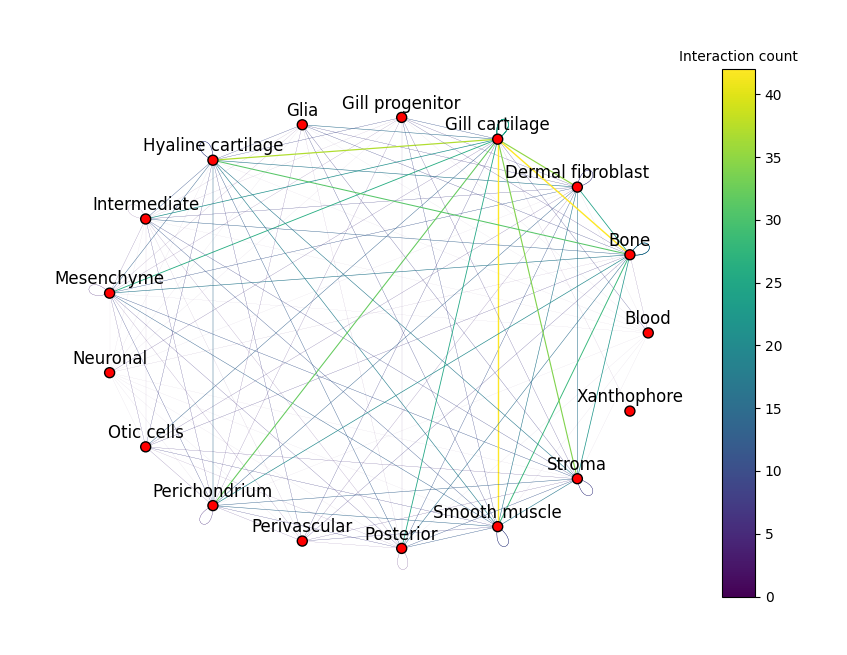

In [13]:
_ = rl.hairball(
    adata,
    min_perc=net_min_perc,
    interaction_score=net_interaction_score,
    interaction_perc=net_interaction_perc,
    save=f"rl_hairball_{net_out_suffix}.pdf",
    title=net_title,
    color_min=net_color_min,
    color_max=net_color_max,
    restrict_to=net_restrict_to,
    show_count=net_show_count,
    node_size = net_node_size,
    node_label_size = net_label_size
)

[INFO] Saving figure to ../figures/0A1_receptor_ligand/rl_cyclone_network.pdf


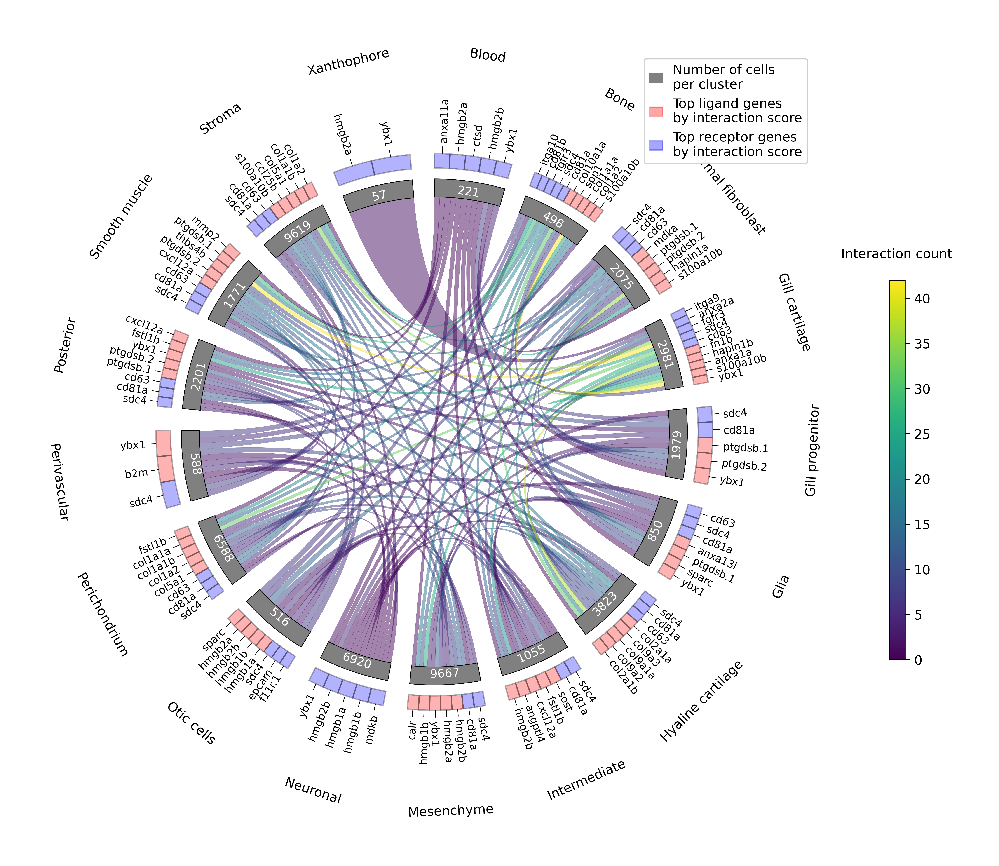

In [14]:
_ = rl.cyclone(
    adata=adata,
    min_perc=net_min_perc,
    interaction_score=net_interaction_score,
    interaction_perc=net_interaction_perc,
    save=f"rl_cyclone_{net_out_suffix}.pdf",
    color_min=net_color_min,
    color_max=net_color_max,
    title=net_title,
    directional=net_directional,
    sector_size_is_cluster_size=net_sector_size_is_cluster_size,
    show_genes=net_show_genes,
    gene_amount=net_gene_amount,
    restrict_to=net_restrict_to,
    report = '02_cyclone_plot.png'
)

__________

### 6.3 - Receptor-ligand connections
Show a detailed view on receptor-ligand pairs and their strength between groups.

<h1><center>⬐ Fill in input data here ⬎</center></h1>

In [15]:
## Connection plot
con_restrict_to = None  # Restrict plot to given cluster names.
con_figsize = (6, 7)  # Figure size
con_out_suffix="connectionPlot"  # Suffix of output file
con_title = None  # Plot title
con_filter = "receptor_score > 0.5 & ligand_score > 0.5 & interaction_score > 2 & receptor_percent >= 60 & ligand_percent >= 60"  # Conditions to filter the interaction table
con_lw_multiplier = 2  # Linewidth multiplier
con_wspace = 0.4  # Width between plots
con_lig_whitelist = None  # List of ligand genes that should be exclusively shown.
con_rec_whitelist = None  # List of receptor genes that should be exclusively shown.
con_dot_size = (10, 100)  # Min and max size of the dots.
con_line_colors = "rainbow" #  Color scheme used to color the connection lines.
con_dot_colors = "flare"  # Color scheme used to color the dots.
con_xlabel_order = None  # A list of all xlabels. Will order the xlabels in the given order. None = alphabetically
con_alpha_range = None  # A min-max tuple (e.g. `(0, 10)`). Set the legend range of the lines alpha values. None = use data min and max.
con_rec_hue_range = None  # A min-max tuple (e.g. `(2, 5)`). Set the legend range of the receptor dot colors. None = use data min and max.
con_lig_hue_range = None  # Same as above but for ligand.
con_rec_size_range = (1, 100)  # A min-max tuple (e.g. `(2, 5)`). Set the legend range of the receptor dot sizes. None = use data min and max.
con_lig_size_range = (1, 100)  # Same as above but for ligand.

_______

[INFO] Saving figure to ../figures/0A1_receptor_ligand/rl_connectionPlot.pdf


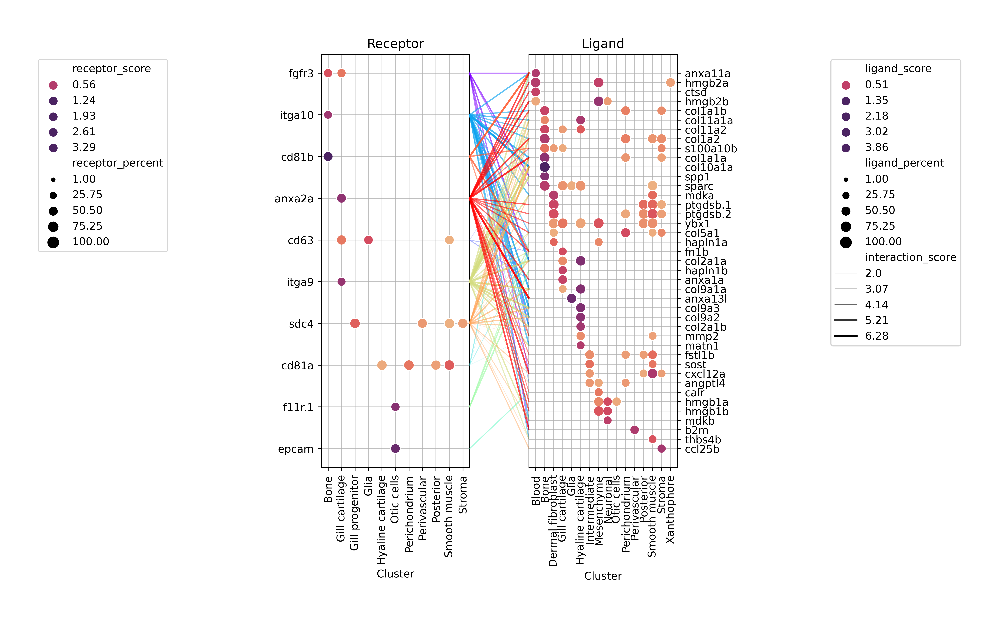

In [16]:
_ = rl.connectionPlot(
    adata=adata,
    restrict_to=con_restrict_to,
    figsize=con_figsize,
    connection_alpha="interaction_score",
    save=f"rl_{con_out_suffix}.pdf",
    title=con_title,
    receptor_cluster_col="receptor_cluster",
    receptor_col="receptor_gene",
    receptor_hue="receptor_score",
    receptor_hue_range=con_rec_hue_range,
    receptor_size="receptor_percent",
    receptor_size_range=con_rec_size_range,
    receptor_genes=con_rec_whitelist,
    ligand_cluster_col="ligand_cluster",
    ligand_col="ligand_gene",
    ligand_hue="ligand_score",
    ligand_hue_range=con_lig_hue_range,
    ligand_size="ligand_percent",
    ligand_size_range=con_lig_size_range,
    ligand_genes=con_lig_whitelist,
    filter=con_filter,
    lw_multiplier=con_lw_multiplier,
    dot_size=con_dot_size,
    wspace=con_wspace,
    line_colors=con_line_colors,
    dot_colors=con_dot_colors,
    xlabel_order=con_xlabel_order,
    alpha_range=con_alpha_range,
    report='03_connectionPlot.png'
)

__________

## 7 - Get interaction table

Filter and write receptor ligand interactions table from the anndata object to a .tsv file. 

<h1><center>⬐ Fill in input data here ⬎</center></h1>

In [17]:
## Filter for interaction table
tab_min_perc = 0  # Minimum percent of cells in a cluster that express the ligand/ receptor gene.
tab_interaction_score = 0  # Filter receptor-ligand interactions below given score.
tab_interaction_perc = 90  # Filter receptor-ligand interactions below the given percentile. Overwrite `interaction_score`.
tab_out_suffix = "interaction_table"  # file name suffix
group_a = None  # List of cluster names that must be present in any given receptor-ligand interaction.
group_b = None  # List of cluster names that must be present in any given receptor-ligand interaction.

_______

In [18]:
interaction_table = rl.get_interactions(
    adata,
    min_perc = tab_min_perc,
    interaction_score = tab_interaction_score,
    interaction_perc = tab_interaction_perc,
    group_a = group_a,
    group_b = group_b,
    save = f"rl_{tab_out_suffix}.tsv"
)

## 8 - Saving adata

In [19]:
import anndata
anndata.settings.allow_write_nullable_strings = True

# convert rl-database columns to str
adata.uns["receptor-ligand"]["database"] = adata.uns["receptor-ligand"]["database"].convert_dtypes()

In [20]:
utils.adata.save_h5ad(adata, "anndata_0A1.h5ad")

[INFO] The adata object was saved to: ../adatas/anndata_0A1.h5ad


In [21]:
settings.close_logfile()